In [28]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [29]:
# Load historical stock data for a given ticker
ticker = "AAPL" # Stock ticker symbol (e.g., Apple Inc.)

# Download historical data from Yahoo Finance
df = yf.download(ticker, start="2022-01-01")

# Display the first few rows and shape of the DataFrame
print(df.head())
print(df.shape)

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103638  178.954976  173.895938  174.013357  104487900
2022-01-04  175.843216  179.013683  175.275662  178.710339   99310400
2022-01-05  171.165802  176.303125  170.891813  175.755146   94537600
2022-01-06  168.308533  171.537711  167.956258  168.993506   96904000
2022-01-07  168.474884  170.402605  167.359351  169.179433   86709100
(1042, 5)


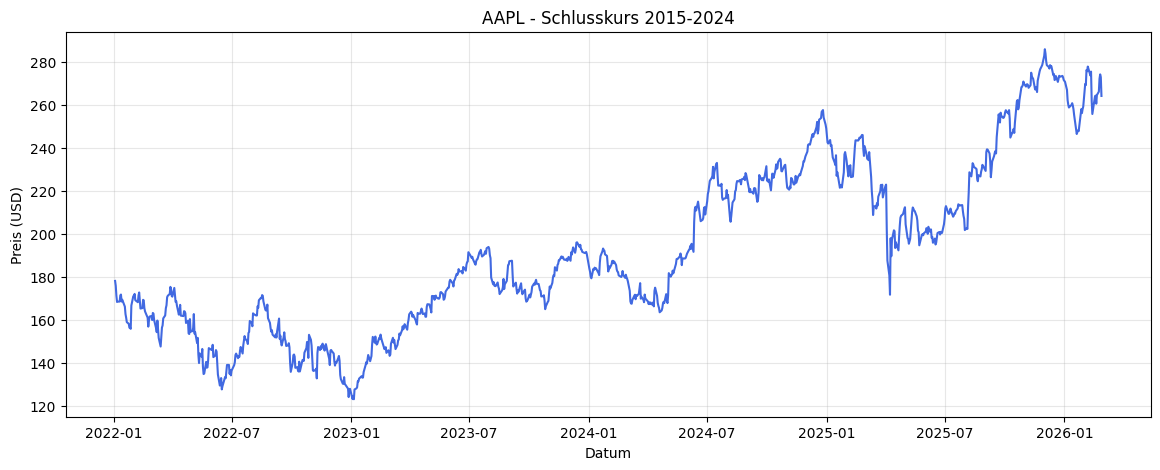

Ticker         AAPL
count   1042.000000
mean     192.611453
std       39.360503
min      123.046806
25%      162.855457
50%      185.571838
75%      224.386024
max      285.922455


In [30]:
# Data Visualization: Plot historical closing prices
plt.figure(figsize=(14, 5))
plt.plot(df["Close"], color="royalblue", linewidth=1.5)
plt.title(f"{ticker} - Closing Price 2015-2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.show()

# Display statistical summary of 'Close' prices
print(df["Close"].describe())

In [31]:
# Data Preprocessing

# Extract and scale 'Close' prices using MinMaxScaler
close_prices = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

# Function to create sequences for time series forecasting
# Each sequence consists of `seq_length` previous data points to predict the next point.
def create_sequences(data, seq_length = 60):
    X, y = [], []
    for i in range(seq_length, len(data)):
      X.append(data[i-seq_length:i])
      y.append(data[i])
    return np.array(X), np.array(y)

# Create sequences and split data into training and testing sets
X, y = create_sequences(scaled_data)
split = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# Convert numpy arrays to PyTorch FloatTensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

# Print shapes of training and testing datasets
print(f"Training Samples: {X_train.shape}")
print(f"Test Samples: {X_test.shape}")

Training Samples: torch.Size([785, 60, 1])
Test Samples: torch.Size([197, 60, 1])


In [32]:
# LSTM Model Definition

class LSTMModel(nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        # LSTM layer with dropout for regularization
        self.lstm = nn.LSTM(input_size=input_size,
                           hidden_size=hidden_size,
                           num_layers=num_layers,
                           batch_first=True,
                           dropout=0.2)
        # Fully connected layer to map LSTM output to final prediction
        self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
        # Pass input through LSTM and then through the fully connected layer
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Create model instance, define loss function (MSE), and optimizer (Adam)
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Print the model architecture
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Epoch 0/50 - Loss: 0.025414
Epoch 10/50 - Loss: 0.003961
Epoch 20/50 - Loss: 0.001907
Epoch 30/50 - Loss: 0.001823
Epoch 40/50 - Loss: 0.001662


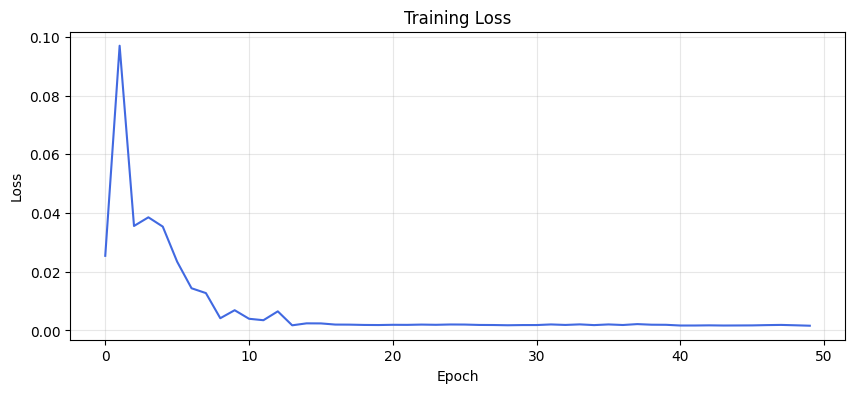

In [33]:
# Prepare data for training using TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

# Training Loop Configuration
epochs = 50
train_losses = []

# Iterate over epochs and batches to train the model
for epoch in range(epochs):
    model.train() # Set model to training mode
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Calculate and store average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Print loss periodically
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.6f}")

# Plotting the Training Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color="royalblue")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

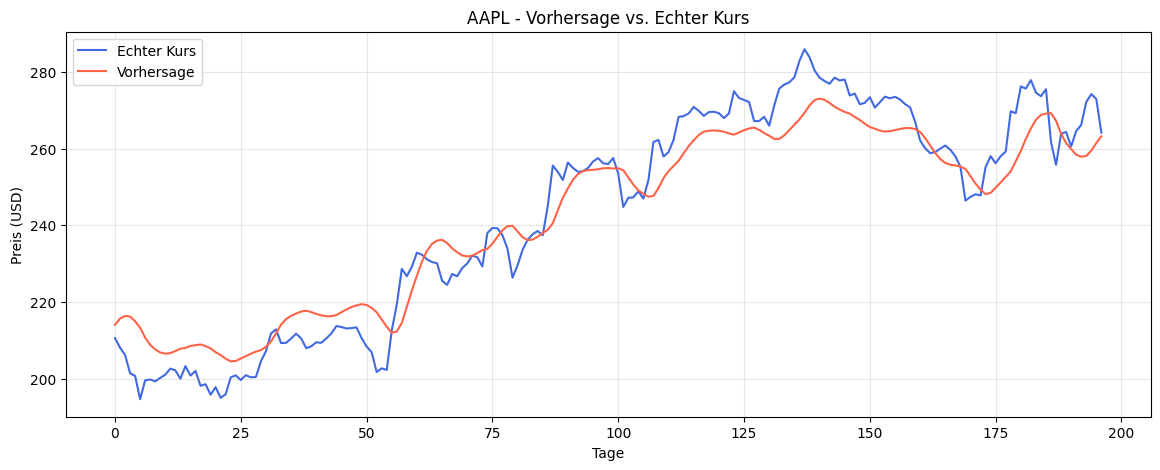

MAE:  6.54$
RMSE: 7.71$


In [35]:
# Model Evaluation

# Set model to evaluation mode and generate predictions on the test set
model.eval()
with torch.no_grad():
    predictions = model(X_test)

# Inverse transform predictions and actual values to original scale
predictions = scaler.inverse_transform(predictions.numpy())
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Visualize Predictions vs. Actual Values
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, color="royalblue", linewidth=1.5, label="Actual Price")
plt.plot(predictions, color="tomato", linewidth=1.5, label="Prediction")
plt.title(f"{ticker} - Prediction vs. Actual Price")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate and print evaluation metrics: MAE and RMSE
mae = np.mean(np.abs(predictions - y_test_actual))
rmse = np.sqrt(np.mean((predictions - y_test_actual)**2))
print(f"MAE:  {mae:.2f}$")
print(f"RMSE: {rmse:.2f}$")

In [34]:
# Future Price Prediction - Predict tomorrow's closing price
model.eval()

# Get the last sequence of scaled data for prediction
last_sequence = scaled_data[-60:]
last_sequence = torch.FloatTensor(last_sequence).unsqueeze(0)

# Make a prediction for the next day's price
with torch.no_grad():
    next_day_scaled = model(last_sequence)

# Inverse transform the scaled prediction to get the actual dollar value
next_day_price = scaler.inverse_transform(next_day_scaled.numpy())

# Get the last known closing price from the DataFrame
last_price = df['Close'].iloc[-1].values[0]

# Print the last known closing price and the predicted price
print(f"Last known closing price: ${last_price:.2f}")
print(f"Predicted price for the next trading day: ${next_day_price[0][0]:.2f}")

Letzter bekannter Schlusskurs: $264.18
Vorhergesagter Kurs für den nächsten Handelstag: $263.40
